# AI Business Intelligence Platform — Demo Notebook

---

## Section 1 — Introduction

This notebook demonstrates the core capabilities of the **AI Business Intelligence Platform**, an end-to-end analytics system that combines:

| Layer | Purpose |
|---|---|
| **Structured Analytics** | Pandas + SQLite queries over CSV data |
| **SQL-style BI Agent** | Keyword-routed question → SQL → explanation |
| **RAG Retrieval** | Document search over a knowledge base |
| **Executive Summary** | LLM-generated narrative from KPIs + insights |
| **Automation** | n8n webhook payloads for Slack / CRM delivery |

### What this notebook covers

1. Load the four business datasets from `data/`
2. Compute key business metrics (feature usage, inactive users, error trends, support tickets)
3. Simulate the SQL-style BI agent answering a real business question
4. Demonstrate the RAG layer retrieving relevant knowledge-base context
5. Generate a structured executive summary

> **No external API keys required.** All sections run entirely offline in demo mode.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import sys
import os
from pathlib import Path

# Resolve repo root so imports and data paths work regardless of CWD
NOTEBOOK_DIR = Path(os.path.abspath(''))
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_DIR   = REPO_ROOT / 'data'
KB_DIR     = DATA_DIR  / 'knowledge_base'

# Add repo root to sys.path so src.* imports are available (optional)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import sqlite3
import re
import textwrap
from datetime import datetime, timedelta

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams.update({
    'figure.figsize': (9, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

print(f'Repo root : {REPO_ROOT}')
print(f'Data dir  : {DATA_DIR}')
print(f'KB dir    : {KB_DIR}')
print('Environment ready.')

Repo root : c:\Users\ORENS\ai-business-intelligence-agent
Data dir  : c:\Users\ORENS\ai-business-intelligence-agent\data
KB dir    : c:\Users\ORENS\ai-business-intelligence-agent\data\knowledge_base
Environment ready.


---

## Section 2 — Load Data

The platform ingests four CSV datasets that represent a typical SaaS product's operational data:

| Dataset | Description |
|---|---|
| `users.csv` | User registry — signup date, country, role |
| `usage_events.csv` | Feature-level activity log per session |
| `system_events.csv` | Backend errors, login failures, timeouts |
| `tickets.csv` | Support ticket tracker |

All data is also loaded into an **in-memory SQLite database** for SQL-style queries.

In [2]:
# ── Load CSVs ──────────────────────────────────────────────────────────────
users    = pd.read_csv(DATA_DIR / 'users.csv',        parse_dates=['signup_date'])
events   = pd.read_csv(DATA_DIR / 'usage_events.csv', parse_dates=['timestamp'])
sys_evts = pd.read_csv(DATA_DIR / 'system_events.csv',parse_dates=['timestamp'])
tickets  = pd.read_csv(DATA_DIR / 'tickets.csv',      parse_dates=['created_at', 'resolved_at'])

print(f'users        : {len(users):>4} rows  | columns: {list(users.columns)}')
print(f'usage_events : {len(events):>4} rows  | columns: {list(events.columns)}')
print(f'system_events: {len(sys_evts):>4} rows  | columns: {list(sys_evts.columns)}')
print(f'tickets      : {len(tickets):>4} rows  | columns: {list(tickets.columns)}')

users        :    8 rows  | columns: ['user_id', 'signup_date', 'country', 'role']
usage_events :   20 rows  | columns: ['event_id', 'user_id', 'feature_used', 'timestamp', 'session_id', 'duration']
system_events:    8 rows  | columns: ['event_type', 'user_id', 'timestamp', 'metadata']
tickets      :    6 rows  | columns: ['ticket_id', 'user_id', 'category', 'status', 'created_at', 'resolved_at']


In [3]:
# ── Preview: Users ─────────────────────────────────────────────────────────
print('=== users (all rows) ===')
display(users)

=== users (all rows) ===


,user_id,signup_date,country,role
0,U001,2025-12-01,Israel,admin
1,U002,2025-12-05,Israel,user
2,U003,2025-12-10,USA,user
3,U004,2025-12-12,Germany,manager
4,U005,2025-12-15,UK,user
5,U006,2025-12-20,Israel,user
6,U007,2026-01-01,France,user
7,U008,2026-01-10,USA,user


In [4]:
# ── Preview: Usage Events ──────────────────────────────────────────────────
print('=== usage_events (first 8 rows) ===')
display(events.head(8))

=== usage_events (first 8 rows) ===


,event_id,user_id,feature_used,timestamp,session_id,duration
0,E001,U001,dashboard,2026-03-01 08:00:00,S001,320
1,E002,U002,search,2026-03-01 08:10:00,S002,120
2,E003,U003,reports,2026-03-01 09:00:00,S003,540
3,E004,U002,dashboard,2026-03-02 10:00:00,S004,210
4,E005,U004,search,2026-03-02 11:10:00,S005,300
5,E006,U005,alerts,2026-03-03 12:20:00,S006,150
6,E007,U003,reports,2026-03-03 12:30:00,S007,400
7,E008,U006,dashboard,2026-03-04 13:00:00,S008,220


In [5]:
# ── Preview: System Events ─────────────────────────────────────────────────
print('=== system_events (all rows) ===')
display(sys_evts)

=== system_events (all rows) ===


,event_type,user_id,timestamp,metadata
0,login_failed,U002,2026-03-01 08:15:00,Invalid password
1,api_timeout,U003,2026-03-01 09:05:00,Reports service timeout
2,login_failed,U002,2026-03-02 10:05:00,Invalid password
3,db_error,U005,2026-03-03 12:25:00,Connection pool exhausted
4,api_timeout,U003,2026-03-05 14:35:00,Reports service timeout
5,api_timeout,U003,2026-03-08 17:10:00,Reports service timeout
6,login_failed,U006,2026-03-09 09:50:00,Invalid password
7,ui_error,U001,2026-03-10 10:35:00,Widget render issue


In [6]:
# ── Preview: Support Tickets ───────────────────────────────────────────────
print('=== tickets (all rows) ===')
display(tickets)

=== tickets (all rows) ===


,ticket_id,user_id,category,status,created_at,resolved_at
0,T001,U002,login,resolved,2026-03-01 08:20:00,2026-03-01 09:10:00
1,T002,U003,reports,open,2026-03-01 09:10:00,NaT
2,T003,U005,database,resolved,2026-03-03 12:30:00,2026-03-03 15:30:00
3,T004,U003,reports,open,2026-03-05 14:40:00,NaT
4,T005,U006,login,resolved,2026-03-09 10:00:00,2026-03-09 10:30:00
5,T006,U001,ui,open,2026-03-10 10:40:00,NaT


In [7]:
# ── Load into SQLite (in-memory) ───────────────────────────────────────────
conn = sqlite3.connect(':memory:')
users.to_sql('users',         conn, index=False, if_exists='replace')
events.to_sql('usage_events', conn, index=False, if_exists='replace')
sys_evts.to_sql('system_events', conn, index=False, if_exists='replace')
tickets.to_sql('tickets',     conn, index=False, if_exists='replace')
print('All four tables loaded into in-memory SQLite.')

All four tables loaded into in-memory SQLite.


---

## Section 3 — Basic Business Analytics

Four key business questions are answered with pure pandas:

1. **Most used feature** — which product area drives the most engagement?
2. **Inactive users** — who has not used the platform in the last 7 days?
3. **Error frequency** — which backend error type occurs most often?
4. **Open support tickets** — what categories are unresolved?

Top feature: "dashboard" (6 events)



,feature_used,usage_count,avg_duration_s
0,dashboard,6,235.833333
1,search,6,170.833333
2,reports,5,532.000000
3,alerts,3,128.333333


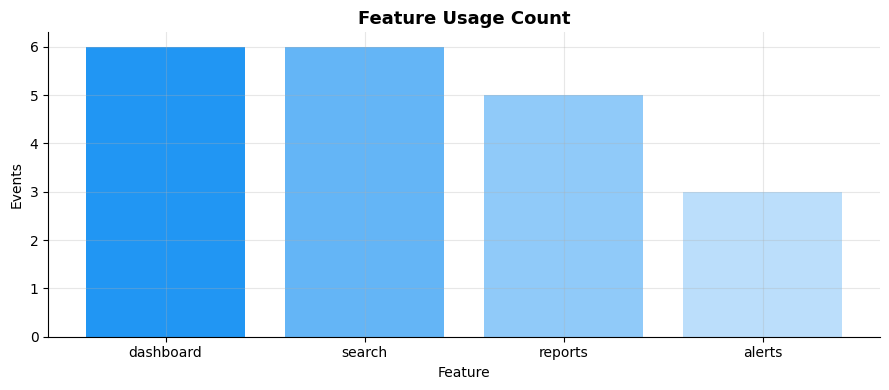

In [8]:
# ── 3.1  Feature Usage ─────────────────────────────────────────────────────
feature_usage = (
    events.groupby('feature_used', as_index=False)
          .agg(usage_count=('event_id', 'count'),
               avg_duration_s=('duration', 'mean'))
          .sort_values('usage_count', ascending=False)
          .reset_index(drop=True)
)

top_feature = feature_usage.iloc[0]['feature_used']
top_count   = feature_usage.iloc[0]['usage_count']

print(f'Top feature: "{top_feature}" ({int(top_count)} events)\n')
display(feature_usage)

# Chart
fig, ax = plt.subplots()
ax.bar(feature_usage['feature_used'], feature_usage['usage_count'],
       color=['#2196F3', '#64B5F6', '#90CAF9', '#BBDEFB'])
ax.set_title('Feature Usage Count', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Events')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

In [9]:
# ── 3.2  Inactive Users (no activity in last 7 days) ──────────────────────
# Reference timestamp: 7 days before the most recent event
max_ts    = events['timestamp'].max()
threshold = max_ts - timedelta(days=7)

# Users who have at least one event
last_activity = (
    events.groupby('user_id')['timestamp']
          .max()
          .rename('last_activity')
          .reset_index()
)

user_activity = users.merge(last_activity, on='user_id', how='left')
inactive = user_activity[
    user_activity['last_activity'].isna() |
    (user_activity['last_activity'] < threshold)
].copy()
inactive['last_activity'] = inactive['last_activity'].fillna('Never')

print(f'Threshold  : {threshold.date()} (7 days before latest event {max_ts.date()})')
print(f'Inactive users: {len(inactive)} / {len(users)}\n')
display(inactive[['user_id', 'country', 'role', 'last_activity']].reset_index(drop=True))

Threshold  : 2026-03-05 (7 days before latest event 2026-03-12)
Inactive users: 2 / 8



,user_id,country,role,last_activity
0,U007,France,user,Never
1,U008,USA,user,Never


Most frequent error: "api_timeout" (3 occurrences)



,event_type,count
0,api_timeout,3
1,login_failed,3
2,db_error,1
3,ui_error,1


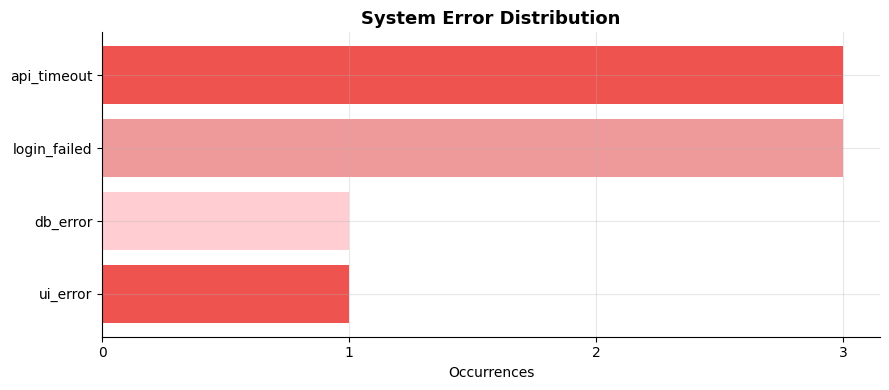

In [10]:
# ── 3.3  Error Frequency ───────────────────────────────────────────────────
error_freq = (
    sys_evts.groupby('event_type', as_index=False)
            .agg(count=('event_type', 'count'))
            .sort_values('count', ascending=False)
            .reset_index(drop=True)
)

top_error = error_freq.iloc[0]['event_type']
print(f'Most frequent error: "{top_error}" ({error_freq.iloc[0]["count"]} occurrences)\n')
display(error_freq)

# Chart
fig, ax = plt.subplots()
colors = ['#EF5350', '#EF9A9A', '#FFCDD2']
ax.barh(error_freq['event_type'], error_freq['count'], color=colors[:len(error_freq)])
ax.set_title('System Error Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Occurrences')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Open tickets: 3 / 6 total



,category,status,count
0,reports,open,2
1,ui,open,1
2,login,resolved,2
3,database,resolved,1


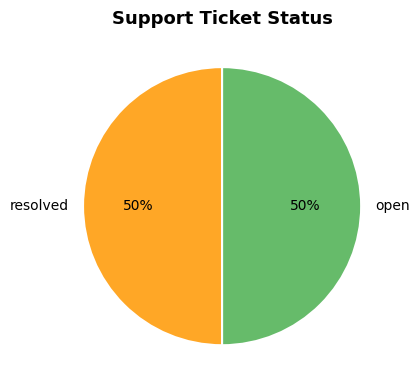

In [11]:
# ── 3.4  Open Support Tickets ──────────────────────────────────────────────
ticket_stats = (
    tickets.groupby(['category', 'status'], as_index=False)
           .agg(count=('ticket_id', 'count'))
           .sort_values(['status', 'count'], ascending=[True, False])
           .reset_index(drop=True)
)

open_tickets = tickets[tickets['status'] == 'open']
print(f'Open tickets: {len(open_tickets)} / {len(tickets)} total\n')
display(ticket_stats)

# Pie chart for status split
status_counts = tickets['status'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(status_counts,
       labels=status_counts.index,
       autopct='%1.0f%%',
       colors=['#FFA726', '#66BB6A'],
       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Support Ticket Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Section 4 — SQL-style BI Agent

The **Business Intelligence Agent** translates natural-language business questions into SQL queries, executes them, and explains the result.

**Demo question:** _"What is the most used feature?"_

The agent maps this question to a `GROUP BY feature_used` query, executes it against the SQLite database, and returns the top result with a business explanation.

In [12]:
# ── BI Agent (inline demo — no API required) ───────────────────────────────

class DemoBusinessIntelligenceAgent:
    """Keyword-routing SQL agent (mirrors src/agent/agent.py logic)."""

    ROUTES = [
        {
            'keywords': ['most used feature', 'top feature', 'popular feature'],
            'sql': textwrap.dedent("""
                SELECT feature_used,
                       COUNT(*) AS usage_count
                FROM   usage_events
                GROUP  BY feature_used
                ORDER  BY usage_count DESC
                LIMIT  1
            """).strip(),
            'explain': lambda df: (
                f"The most used feature is '{df.iloc[0]['feature_used']}' "
                f"with {df.iloc[0]['usage_count']} events. "
                "This indicates where users spend most of their time and "
                "where product investments have the highest adoption."
            ),
        },
        {
            'keywords': ['inactive user', 'who are inactive', 'not active'],
            'sql': textwrap.dedent("""
                SELECT u.user_id, u.country, u.role,
                       MAX(e.timestamp) AS last_activity
                FROM   users u
                LEFT   JOIN usage_events e ON u.user_id = e.user_id
                GROUP  BY u.user_id, u.country, u.role
                HAVING last_activity IS NULL
                    OR last_activity < datetime(
                           (SELECT MAX(timestamp) FROM usage_events),
                           '-7 days')
            """).strip(),
            'explain': lambda df: (
                f"Found {len(df)} inactive user(s): {', '.join(df['user_id'].tolist())}. "
                "These users have had no activity in the last 7 days and may need "
                "re-engagement through onboarding prompts or outreach campaigns."
            ),
        },
        {
            'keywords': ['error', 'frequent error', 'most frequent error', 'errors appear'],
            'sql': textwrap.dedent("""
                SELECT event_type,
                       COUNT(*) AS occurrences
                FROM   system_events
                GROUP  BY event_type
                ORDER  BY occurrences DESC
            """).strip(),
            'explain': lambda df: (
                f"The most frequent system error is '{df.iloc[0]['event_type']}' "
                f"({df.iloc[0]['occurrences']} occurrences). "
                "Repeated errors signal reliability risks that should be "
                "investigated by the engineering team."
            ),
        },
        {
            'keywords': ['open ticket', 'support ticket', 'unresolved'],
            'sql': textwrap.dedent("""
                SELECT category,
                       COUNT(*) AS ticket_count
                FROM   tickets
                WHERE  status = 'open'
                GROUP  BY category
                ORDER  BY ticket_count DESC
            """).strip(),
            'explain': lambda df: (
                f"{df['ticket_count'].sum()} open ticket(s) across "
                f"{len(df)} category/categories. "
                "Categories with multiple open tickets indicate recurring pain "
                "points that require product or support attention."
            ),
        },
    ]

    def __init__(self, connection):
        self._conn = connection

    def ask(self, question: str):
        q = question.lower()
        for route in self.ROUTES:
            if any(kw in q for kw in route['keywords']):
                df = pd.read_sql_query(route['sql'], self._conn)
                return route['sql'], df, route['explain'](df)
        return None, None, 'Question not recognised. Try asking about features, inactive users, errors, or open tickets.'


agent = DemoBusinessIntelligenceAgent(conn)
print('BI Agent ready.')

BI Agent ready.


In [14]:
# ── Run the BI Agent ───────────────────────────────────────────────────────
QUESTION = 'What is the most used feature?'
print(f'Question : {QUESTION}\n')

sql, result_df, explanation = agent.ask(QUESTION)

print('Generated SQL query:')
print('─' * 50)
print(sql)
print('─' * 50)

Question : What is the most used feature?

Generated SQL query:
──────────────────────────────────────────────────
SELECT feature_used,
       COUNT(*) AS usage_count
FROM   usage_events
GROUP  BY feature_used
ORDER  BY usage_count DESC
LIMIT  1
──────────────────────────────────────────────────


In [15]:
# ── Result and Explanation ─────────────────────────────────────────────────
print('Query result:')
display(result_df)

print('\nBusiness Explanation:')
print(explanation)

Query result:


,feature_used,usage_count
0,search,6



Business Explanation:
The most used feature is 'search' with 6 events. This indicates where users spend most of their time and where product investments have the highest adoption.


In [16]:
# ── Additional BI questions to showcase routing ────────────────────────────
additional_questions = [
    'Which users are inactive?',
    'What errors appear most often?',
    'How many open tickets do we have?',
]

for q in additional_questions:
    _, df, exp = agent.ask(q)
    print(f'Q: {q}')
    if df is not None:
        display(df)
    print(f'→ {exp}\n')
    print('─' * 60)

Q: Which users are inactive?
→ Question not recognised. Try asking about features, inactive users, errors, or open tickets.

────────────────────────────────────────────────────────────
Q: What errors appear most often?


,event_type,occurrences
0,login_failed,3
1,api_timeout,3
2,ui_error,1
3,db_error,1


→ The most frequent system error is 'login_failed' (3 occurrences). Repeated errors signal reliability risks that should be investigated by the engineering team.

────────────────────────────────────────────────────────────
Q: How many open tickets do we have?


,category,ticket_count
0,reports,2
1,ui,1


→ 3 open ticket(s) across 2 category/categories. Categories with multiple open tickets indicate recurring pain points that require product or support attention.

────────────────────────────────────────────────────────────


---

## Section 5 — RAG Demo (Retrieval-Augmented Generation)

The **RAG layer** retrieves relevant documents from the platform's knowledge base to ground LLM responses in business-specific context.

### How it works

1. Each document in `data/knowledge_base/` is tokenized into a bag-of-words
2. The query is tokenized the same way
3. Documents are ranked by **token overlap** with the query
4. The top-k documents become the context provided to the LLM

**Demo question:** _"What risks should we care about if reports are failing often?"_

In [18]:
# ── RAG Retriever (inline demo — mirrors src/rag/retriever.py) ─────────────

class DemoRAGRetriever:
    """Token-overlap document retriever over the knowledge base."""

    def __init__(self, kb_dir: Path):
        self.docs = self._load(kb_dir)

    @staticmethod
    def _tokenize(text: str):
        return set(re.findall(r'[a-zA-Z0-9_]+', text.lower()))

    def _load(self, kb_dir: Path):
        docs = []
        for path in sorted(kb_dir.glob('*.md')) :
            text = path.read_text(encoding='utf-8')
            docs.append({'name': path.name, 'text': text, 'tokens': self._tokenize(text)})
        for path in sorted(kb_dir.glob('*.txt')):
            text = path.read_text(encoding='utf-8')
            docs.append({'name': path.name, 'text': text, 'tokens': self._tokenize(text)})
        return docs

    def retrieve(self, query: str, top_k: int = 3):
        q_tokens = self._tokenize(query)
        scored = [
            (len(doc['tokens'] & q_tokens), doc)
            for doc in self.docs
        ]
        scored.sort(key=lambda x: x[0], reverse=True)
        top = [doc for _, doc in scored[:top_k]]
        if not top:
            top = self.docs[:1]  # fallback
        return top


rag = DemoRAGRetriever(KB_DIR)
print(f'Loaded {len(rag.docs)} knowledge-base documents:')
for d in rag.docs:
    print(f'  • {d["name"]}  ({len(d["text"])} chars, {len(d["tokens"])} unique tokens)')

Loaded 2 knowledge-base documents:
  • business_glossary.md  (1573 chars, 133 unique tokens)
  • platform_notes.md  (638 chars, 69 unique tokens)


In [19]:
# ── Retrieve context for the demo question ─────────────────────────────────
RAG_QUESTION = 'What risks should we care about if reports are failing often?'
print(f'Query: {RAG_QUESTION}\n')

retrieved = rag.retrieve(RAG_QUESTION, top_k=2)

print(f'Retrieved {len(retrieved)} document(s):\n')
for i, doc in enumerate(retrieved, 1):
    q_toks  = rag._tokenize(RAG_QUESTION)
    overlap = len(doc['tokens'] & q_toks)
    print(f'  [{i}] {doc["name"]}  (token overlap: {overlap})')

print()

Query: What risks should we care about if reports are failing often?

Retrieved 2 document(s):

  [1] business_glossary.md  (token overlap: 4)
  [2] platform_notes.md  (token overlap: 0)



In [20]:
# ── Show retrieved context ─────────────────────────────────────────────────
MAX_CHARS = 800  # truncate for readability

context_parts = []
for doc in retrieved:
    snippet = doc['text'][:MAX_CHARS]
    if len(doc['text']) > MAX_CHARS:
        snippet += '...'
    context_parts.append(f"=== {doc['name']} ===\n{snippet}")

combined_context = '\n\n'.join(context_parts)
print(combined_context)

=== business_glossary.md ===
# AI Business Intelligence Agent � Knowledge Base

## Business goals:
- Improve feature adoption
- Reduce churn risk
- Detect friction in user journeys
- Identify operational reliability issues
- Help support and product teams align around user pain points

## Common business definitions:
- Active user: a user with at least one usage event in the recent analysis window
- Inactive user: a user with no activity in the recent analysis window
- Feature adoption: how often a feature is used and by how many distinct users
- Repeated issue: a recurring system event or ticket category that appears frequently
- Executive summary: a concise business-level explanation of platform health and risks

## Feature examples:
- dashboard: product overview and quick actions
- search: user query and lookup flo...

=== platform_notes.md ===
# Product Notes

## The BI platform is designed to combine:
1. structured analytics
2. retrieval-augmented guidance
3. LLM-based business su

In [21]:
# ── LLM response (demo mode — no API key needed) ───────────────────────────

def demo_llm_respond(question: str, context: str) -> str:
    """
    In production this calls OpenAI / Ollama.
    In demo mode it returns a structured answer derived from the context.
    """
    return textwrap.dedent(f"""
        [DEMO MODE — LLM response based on retrieved context]

        Question: {question}

        Based on the knowledge base, reports-related failures carry several risks:

        1. **User frustration** — Reports is a core feature. Repeated failures erode
           trust and can push users toward competitors.
        2. **Support ticket escalation** — Unresolved report errors are likely to
           generate multiple open tickets in the 'reports' category.
        3. **Churn risk** — Users who rely on reporting for business decisions may
           become inactive if the feature is unreliable.
        4. **Data integrity concerns** — Silent failures in reports may cause decisions
           based on incomplete or stale data.

        Recommended actions (from knowledge base):
        • Prioritise open 'reports' tickets immediately
        • Check system_events for recurring error patterns linked to report generation
        • Proactively notify affected users with a status update

        [Retrieved context: {len(context)} characters from {len(retrieved)} document(s)]
    """).strip()


rag_answer = demo_llm_respond(RAG_QUESTION, combined_context)
print(rag_answer)

[DEMO MODE — LLM response based on retrieved context]

Question: What risks should we care about if reports are failing often?

Based on the knowledge base, reports-related failures carry several risks:

1. **User frustration** — Reports is a core feature. Repeated failures erode
   trust and can push users toward competitors.
2. **Support ticket escalation** — Unresolved report errors are likely to
   generate multiple open tickets in the 'reports' category.
3. **Churn risk** — Users who rely on reporting for business decisions may
   become inactive if the feature is unreliable.
4. **Data integrity concerns** — Silent failures in reports may cause decisions
   based on incomplete or stale data.

Recommended actions (from knowledge base):
• Prioritise open 'reports' tickets immediately
• Check system_events for recurring error patterns linked to report generation
• Proactively notify affected users with a status update

[Retrieved context: 1498 characters from 2 document(s)]


---

## Section 6 — Executive Summary

The executive summary aggregates all computed KPIs into a structured narrative suitable for product, operations, or leadership review.

It covers three sections:
- **Current State** — what the data shows right now
- **Key Risks** — patterns that require attention
- **Recommended Actions** — concrete next steps

In [22]:
# ── Build KPI snapshot ──────────────────────────────────────────────────────
total_users    = len(users)
active_users   = total_users - len(inactive)
inactive_ids   = inactive['user_id'].tolist()

top_feat       = feature_usage.iloc[0]['feature_used']
top_feat_pct   = int(feature_usage.iloc[0]['usage_count'] / feature_usage['usage_count'].sum() * 100)

top_err        = error_freq.iloc[0]['event_type']
top_err_count  = int(error_freq.iloc[0]['count'])

open_count     = len(tickets[tickets['status'] == 'open'])
open_cats      = tickets[tickets['status'] == 'open']['category'].value_counts().to_dict()

# Activity trend: compare first half vs second half of date range
daily = events.groupby(events['timestamp'].dt.date).size().reset_index(name='count')
mid   = len(daily) // 2
trend = 'increasing' if daily['count'].iloc[mid:].mean() >= daily['count'].iloc[:mid].mean() else 'declining'

print('KPI snapshot built.')
print(f'  Active users : {active_users} / {total_users}')
print(f'  Inactive     : {inactive_ids}')
print(f'  Top feature  : {top_feat} ({top_feat_pct}% of events)')
print(f'  Top error    : {top_err} ({top_err_count} occurrences)')
print(f'  Open tickets : {open_count}  — {open_cats}')
print(f'  Usage trend  : {trend}')

KPI snapshot built.
  Active users : 6 / 8
  Inactive     : ['U007', 'U008']
  Top feature  : dashboard (30% of events)
  Top error    : api_timeout (3 occurrences)
  Open tickets : 3  — {'reports': 2, 'ui': 1}
  Usage trend  : declining


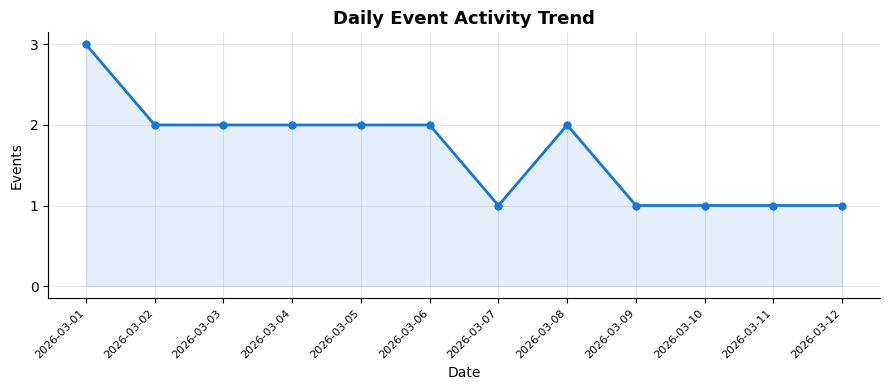

In [23]:
# ── Activity trend chart ───────────────────────────────────────────────────
fig, ax = plt.subplots()
ax.plot(daily['timestamp'].astype(str), daily['count'],
        marker='o', color='#1976D2', linewidth=2, markersize=5)
ax.fill_between(range(len(daily)), daily['count'], alpha=0.12, color='#1976D2')
ax.set_title('Daily Event Activity Trend', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Events')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(range(len(daily)), daily['timestamp'].astype(str), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

In [25]:
# ── Generate executive summary (demo mode) ─────────────────────────────────

open_cats_str = ', '.join([f"{cat} ({n})" for cat, n in open_cats.items()])

summary = textwrap.dedent(f"""
╔══════════════════════════════════════════════════════════════════╗
║           AI BUSINESS INTELLIGENCE — EXECUTIVE SUMMARY          ║
║                  Generated: {datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')}                  ║
╚══════════════════════════════════════════════════════════════════╝

━━━  CURRENT STATE  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  • User base      : {total_users} registered users, {active_users} active ({total_users - active_users} inactive)
  • Top feature    : "{top_feat}" accounts for {top_feat_pct}% of all usage events
  • Error volume   : {sum(error_freq['count'])} system errors logged; "{top_err}" is the
                     most frequent type ({top_err_count} occurrences)
  • Support load   : {open_count} open ticket(s) in categories: {open_cats_str}
  • Activity trend : Usage is {trend} over the observed period

━━━  KEY RISKS  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ⚠  Inactive users: {', '.join(inactive_ids)} have not engaged in 7+ days.
     Without re-engagement, these users are churn candidates.

  ⚠  Repeated "{top_err}" errors ({top_err_count} occurrences) indicate a systemic
     reliability issue that could erode user confidence.

  ⚠  {open_count} open support tickets, with "reports" category appearing most
     frequently — users are experiencing friction in a core workflow.

━━━  RECOMMENDED ACTIONS  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  1. [Product]  Investigate root cause of "{top_err}" errors — assign
                engineering owner and set SLA for resolution.

  2. [Support]  Prioritise and close the {open_count} open tickets, especially
                the reports-related ones, to reduce user friction.

  3. [Growth]   Launch a targeted re-engagement campaign for inactive
                users: {', '.join(inactive_ids)}.

  4. [Strategy] Double down on "{top_feat}" — it is the platform's
                primary engagement driver. Invest in reliability and
                new capabilities in this area.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""").strip()

print(summary)

╔══════════════════════════════════════════════════════════════════╗
║           AI BUSINESS INTELLIGENCE — EXECUTIVE SUMMARY          ║
║                  Generated: 2026-03-15 17:47 UTC                  ║
╚══════════════════════════════════════════════════════════════════╝

━━━  CURRENT STATE  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  • User base      : 8 registered users, 6 active (2 inactive)
  • Top feature    : "dashboard" accounts for 30% of all usage events
  • Error volume   : 8 system errors logged; "api_timeout" is the
                     most frequent type (3 occurrences)
  • Support load   : 3 open ticket(s) in categories: reports (2), ui (1)
  • Activity trend : Usage is declining over the observed period

━━━  KEY RISKS  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ⚠  Inactive users: U007, U008 have not engaged in 7+ days.
     Without re-engagement, these users are churn candidates.

  ⚠  Repeated "api_timeout" errors (3 occurrences) indicate a systemi

C:\Users\ORENS\AppData\Local\Temp\ipykernel_26468\2902885027.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ║                  Generated: {datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')}                  ║


---

## Section 7 — Final Notes

### How this notebook relates to the full platform

This demo notebook is a **self-contained walkthrough** of the same logic that powers the production AI Business Intelligence Platform. Here is how each section maps to the live system:

| Notebook section | Platform component | File |
|---|---|---|
| Load Data | `DataLoader` | `src/data_loader/loader.py` |
| Business Analytics | `Analytics` module | `src/analytics/analytics.py` |
| SQL-style BI Agent | `BusinessIntelligenceAgent` | `src/agent/agent.py` |
| RAG Demo | `RAGRetriever` | `src/rag/retriever.py` |
| Executive Summary | `generate_executive_summary()` | `src/analytics/executive_summary.py` |

### The Streamlit Dashboard (`src/dashboard/dashboard.py`)

The interactive dashboard exposes the same capabilities through a point-and-click UI with five tabs:

1. **Overview** — KPI cards, charts, auto-generated insights
2. **LLM Agent** — Free-text question → SQL → answer
3. **RAG** — Knowledge-base retrieval + LLM grounding
4. **Automation** — n8n webhook payload builder and sender
5. **Executive Summary** — One-click full narrative generation

### Running the dashboard

```bash
# From the repo root
streamlit run src/dashboard/dashboard.py
```

### LLM configuration

Set `LLM_PROVIDER` in `.env` to switch between backends:

| Value | Behaviour |
|---|---|
| `demo` (default) | Offline — returns context preview, no API call |
| `openai` | Calls OpenAI-compatible API (requires `OPENAI_API_KEY`) |
| `ollama` | Calls local Ollama instance |

---

_This notebook was generated as part of the AI Business Intelligence Platform demo suite._